In [3]:
#This code evaluate the performance of the model in each active learning cycle and prepare the dataset for next cycle

import numpy as np
import torch
import torch.optim as optim
import logging
import matplotlib.pyplot as plt
from argparse import ArgumentParser
from torch.autograd import Variable
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.distributions import Normal, OneHotCategorical
import torch.nn.utils as nn_utils
import torch
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
torch.manual_seed(123456)
np.random.seed(123456)


def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0.0)        
class MDN(nn.Module):
    def __init__(self, n_hidden, n_gaussians,n_hidden_layers,bn, dout, dout_value):
        super(MDN, self).__init__()        
        layers = [nn.Linear(41, n_hidden), nn.Tanh()] #Input features
        if bn == 1:
            layers.append(nn.BatchNorm1d(n_hidden))    
        for _ in range(n_hidden_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())
        if dout==1:
            layers.append(nn.Dropout(dout_value))
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())   
        else:
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())       
        self.z_h = nn.Sequential(*layers)       
        self.z_pi = nn.Linear(n_hidden, n_gaussians)
        self.z_sigma = nn.Linear(n_hidden, n_gaussians)
        self.z_mu = nn.Linear(n_hidden, n_gaussians)  
    def forward(self, x):
        z_h = self.z_h(x)
        pi = nn.functional.softmax(self.z_pi(z_h), -1)
        sigma = torch.exp(self.z_sigma(z_h))+ 1e-8
        sigma = torch.clamp(sigma, min=1e-4)
        mu = 0 + (1 - 0) * (torch.tanh(self.z_mu(z_h)) + 1) / 2
        return pi, sigma, mu    
oneDivSqrtTwoPI = 1.0 / np.sqrt(2.0*np.pi) 
def gaussian_distribution(y, mu, sigma):
    result = (y.expand_as(mu) - mu) * torch.reciprocal(sigma)
    result = -0.5 * (result * result)
    return (torch.exp(result) * torch.reciprocal(sigma)) * oneDivSqrtTwoPI
def mdn_loss_fn(pi, sigma, mu, y):
    result = gaussian_distribution(y, mu, sigma) * pi
    result1 = torch.sum(result, dim=1)
    result2 = -torch.log(result1+1e-12)
    return torch.mean(result2)

model = MDN(n_hidden=91, n_gaussians=2,n_hidden_layers=6,bn=0, dout=0, dout_value=0.21738) #BCC Ti-free
model.eval()
optimizer = optim.Adam(model.parameters(), lr=0.00007)

PATH = "checkpoint/model-362.pt" #This should be updated based on the performance of each cycle
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
data_x = np.load('xlo_test.npy')[:,:] #This should be updated in each active learning cycle
data_y = np.load('ylo_test.npy') #This should be updated in each active learning cycle
data_y[:,1]=data_y[:,1]+data_y[:,3] #This line should be acivated only for the initial step with np.load('ylo_test.npy')

data_x_np = torch.tensor(data_x, dtype=torch.float)
data_y_np = torch.tensor(data_y, dtype=torch.float)[:,1:2]  
pi_variable, sigma_variable, mu_variable = model(data_x_np)
loss = mdn_loss_fn(pi_variable, sigma_variable, mu_variable, data_y_np)
weighted_average_mu = torch.sum(pi_variable * mu_variable, dim=-1)
weighted_sigma = torch.sqrt(torch.sum(pi_variable * (sigma_variable ** 2 + (mu_variable - weighted_average_mu.unsqueeze(-1)) ** 2), dim=-1))
weighted_average_mu_np = weighted_average_mu.detach().numpy()
weighted_sigma_np = weighted_sigma.detach().numpy()
n=np.arange(0,weighted_average_mu_np.shape[0],1).reshape(-1,1)
n=np.hstack([n,weighted_average_mu_np.reshape(-1,1),data_y_np]) 
n[:,1] = (n[:, 1] >= 0.9).astype(int)
n[:,2] = (n[:, 2] >= 0.9).astype(int)   
cm = confusion_matrix(n[:,2], n[:,1])
tn, fp, fn, tp = cm.ravel()  
print('Precision=',precision_score(n[:,2], n[:,1]))
print('Recall=',recall_score(n[:,2], n[:,1]))
print('F1=',f1_score(n[:,2], n[:,1]))

def select_500_kmeans_bcc(Xt,n,uncertainty=False,B=500,tau=0.90,use_pca=False, pca_dims=20,random_state=42):  
    yt=n[:,1]
    C_idx = np.where(yt >= tau)[0]
    step = 0
    while C_idx.size < B and tau > 0.0:
        tau = max(0.0, tau - 0.02)
        C_idx = np.where(yt >= tau)[0]
        step += 1
    if C_idx.size < B:
        raise ValueError("Not enough candidates even after lowering threshold.")
    if uncertainty:
        m=np.zeros([0,3])
        for i in range(n.shape[0]):
            if yt[i]>=tau:
                m=np.append(m,n[[i],:],axis=0)
        m=m[np.argsort(m[:,2]),:]
        nm=3*B 
        C_idx=np.copy(m[:nm,0].astype('int')) #This should be updated as follows: ":nm" for high certain route and "-nm:" for low certain route   
    Xc = Xt[C_idx]
    if use_pca and Xc.shape[1] > pca_dims:
        pca = PCA(n_components=pca_dims, random_state=random_state).fit(Xc)
        Xemb = pca.transform(Xc)
    else:
        Xemb = Xc
    km = KMeans(n_clusters=B, n_init=10, random_state=random_state)
    km.fit(Xemb)
    centers = km.cluster_centers_
    labels = km.labels_
    picked = []
    for k in range(B):
        members = np.where(labels == k)[0]
        if members.size == 0:
            d_all = np.linalg.norm(Xemb - centers[k], axis=1)
            picked.append(int(np.argmin(d_all)))
            continue
        Xm = Xemb[members]
        d = np.linalg.norm(Xm - centers[k], axis=1)
        picked.append(members[int(np.argmin(d))])
    picked = np.array(picked, dtype=int)
    picked_unique = np.unique(picked)
    if picked_unique.size < B:
        remaining = np.setdiff1d(np.arange(len(C_idx)), picked_unique, assume_unique=True)
        need = B - picked_unique.size
        picked = np.concatenate([picked_unique, remaining[:need]])
    else:
        picked = picked_unique[:B]
    return C_idx[picked]


#--------Part 1--------------
##Note: only of the part 1 or part 2 should be active 
n=np.arange(0,weighted_average_mu_np.shape[0],1).reshape(-1,1)
n=np.hstack([n,weighted_average_mu_np.reshape(-1,1),weighted_sigma_np.reshape(-1,1)]) 
idx_500 = select_500_kmeans_bcc(data_x, n, uncertainty=False,B=500, tau=0.9, use_pca=False, pca_dims=20, random_state=42) # B should be changed (sample size)
#----------------------------

#--------Part 2--------------
#Note: only of the part 1 or part 2 should be active 
# n=np.arange(0,weighted_average_mu_np.shape[0],1).reshape(-1,1)
# n=np.hstack([n,weighted_average_mu_np.reshape(-1,1),weighted_sigma_np.reshape(-1,1)]) 
# idx_500 = select_500_kmeans_bcc(data_x, n,uncertainty=True,B=200, tau=0.9, use_pca=False, pca_dims=20, random_state=42) # B should be changed (sample size)
#----------------------------

Xadd=data_x[idx_500]
yadd=data_y[idx_500]
n=0
for i in range(yadd.shape[0]):
    if yadd[i,1]>=0.9:
        n=n+1
print('accuracy=',n/yadd.shape[0])
all_idx = np.arange(len(data_x))
test_idx = np.setdiff1d(all_idx, idx_500, assume_unique=True)
X_test = data_x[test_idx]    
y_test = data_y[test_idx]
np.random.seed(42)
num_rows=np.shape(Xadd)[0]
permutation = np.random.permutation(num_rows)
Xadd = Xadd[permutation]
yadd = yadd[permutation]
i=500 #This is sample size and should be updated in each active learning cycle 
cycle=0 #This is id of the next active learning cycle and should be updated in each active learning cycle
with open('xlo_%d.npy' %cycle,'wb') as f:
    np.save(f,Xadd[:int(0.9*i),:])
with open('ylo_%d.npy' %cycle,'wb') as f:
    np.save(f,yadd[:int(0.9*i),:]) 
with open('xlo_val_%d.npy' %cycle,'wb') as f:
    np.save(f,Xadd[int(0.9*i):,:])
with open('ylo_val_%d.npy' %cycle,'wb') as f:
    np.save(f,yadd[int(0.9*i):,:])   
with open('xlo_test_%d.npy' %cycle,'wb') as f:
    np.save(f,X_test)
with open('ylo_test_%d.npy' %cycle,'wb') as f:
    np.save(f,y_test) 

Precision= 0.6123600618913261
Recall= 0.18674882726843756
F1= 0.28621261751818605
accuracy= 0.678


In [4]:
#This is useful in case you want to manually calculate the accuracy of each cycle
A=np.load('ylo_val_0.npy')
B=np.load('ylo_0.npy')
n=0
for i in range(A.shape[0]):
    if A[i,1]>=0.9:
        n=n+1
m=0
for i in range(B.shape[0]):
    if B[i,1]>=0.9:
        m=m+1 
(m+n)/(A.shape[0]+B.shape[0])

0.678

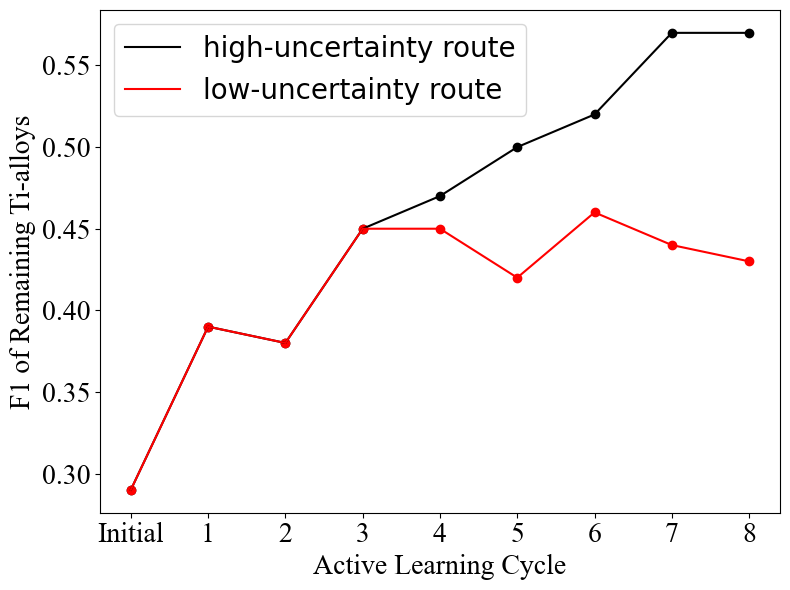

In [33]:
#This code generates Figure 7 of the mansucript. Note that all accuracy, precission, recall, and F1 values were obtained 
#from the code of the earlier part 

import numpy as np
import matplotlib.pyplot as plt

x1=[0,1,2,3,4,5,6,7,8] #i.e., low-certain route
x2=[0,1,2,3,4,5,6,7,8] #i.e., high-certain route

# acc1=[.8,0.74,0.8,0.5,0.63,0.62,0.7,0.61,0.66] 
# acc2=[0.68,0.74,0.8,0.95,0.95,0.87,0.91,0.9,0.93]
      
# precision1=[0.61,0.71,0.78,0.75,0.78,0.76,0.81,0.77,0.79] 
# precision2=[0.61,0.71,0.78,0.75,0.76,0.72,0.67,0.67,0.76]

# recall1=[0.19,0.27,0.25,0.32,0.34,0.37,0.38,0.45,0.45] 
# recall2=[0.19,0.27,0.25,0.32,0.32,0.30,0.35,0.33,0.3]

F11=[0.29,0.39,0.38,0.45,0.47,0.5,0.52,0.57,0.57] 
F12=[0.29,0.39,0.38,0.45,0.45,0.42,0.46,0.44,0.43]

plt.figure(figsize=(8, 6))
plt.scatter(x1,F11,color='k')
plt.plot(x1,F11,color='k',label='High-uncertainty route')
plt.scatter(x2,F12,color='r')
plt.plot(x2,F12,color='r',label='Low-uncertainty route')

plt.xlabel("Active Learning Cycle",fontsize=20, fontname='Times New Roman') 
plt.ylabel("F1 of Remaining Ti-alloys",fontsize=20, fontname='Times New Roman')
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], fontname='Times New Roman')
plt.gca().set_xticklabels(['Initial', 1, 2, 3, 4, 5, 6, 7, 8],
                          fontsize=20,
                          fontname='Times New Roman')

plt.yticks(fontsize=20, fontname='Times New Roman') 
plt.legend(fontsize=20,prop={'family': 'Times New Roman'}) 
plt.tight_layout()
plt.savefig('7d.png', dpi=600)

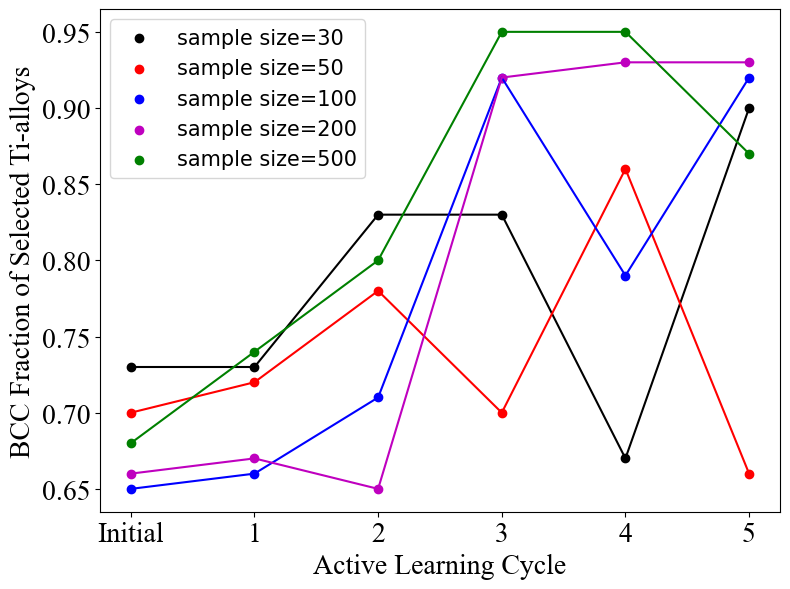

In [7]:
#This code generates Figure 8 of the mansucript. Note that all accuracy, precission, recall, and F1 values were obtained from
#earlier part

x=[0,1,2,3,4,5] 

acc1=[0.73,0.73,0.83,0.83,0.67,0.9]
prec1=[0.61,0.61,0.64,0.64,0.64,0.62]
recall1=[0.19,0.18,0.17,0.19,0.21,0.18]
F11=[0.29,0.28,0.27,0.30,0.32,0.28]

acc2=[0.7,0.72,0.78,0.7,0.86,0.66]
prec2=[0.61,0.61,0.59,0.61,0.63,0.59]
recall2=[0.19,0.2,0.21,0.25,0.24,0.22]
F12=[0.29,0.3,0.31,0.35,0.35,0.32]

acc3=[0.65,0.66,0.71,0.92,0.79,0.92]
prec3=[0.61,0.62,0.63,0.62,0.6,0.59]
recall3=[0.19,0.17,0.22,0.24,0.27,0.31]
F13=[0.29,0.27,0.32,0.35,0.37,0.4]

acc4=[0.66,0.67,0.65,0.92,0.93,0.93]
prec4=[0.61,0.62,0.61,0.71,0.7,0.69]
recall4=[0.19,0.17,0.24,0.24,0.23,0.25]
F14=[0.29,0.27,0.35,0.36,0.34,0.37]

acc5=[0.68,0.74,0.8,0.95,0.95,0.87]
prec5=[0.61,0.71,0.78,0.75,0.76,0.72]
recall5=[0.19,0.27,0.25,0.32,0.32,0.30]
F15=[0.29,0.39,0.38,0.45,0.45,0.42]

n=0 #accuracy=0 precission=1 recall=2 F1=3

metrics = [[acc1, prec1, recall1,F11],[acc2, prec2, recall2,F12],[acc3, prec3, recall3,F13],[acc4, prec4, recall4,F14],[acc5, prec5, recall5,F15]]
plt.figure(figsize=(8, 6))
plt.scatter(x,metrics[0][n],color='k',label='Sample size = 30')
plt.plot(x,metrics[0][n],color='k')
plt.scatter(x,metrics[1][n],color='r',label='Sample size = 50')
plt.plot(x,metrics[1][n],color='r')
plt.scatter(x,metrics[2][n],color='b',label='Sample size = 100')
plt.plot(x,metrics[2][n],color='b')
plt.scatter(x,metrics[3][n],color='m',label='Sample size = 200')
plt.plot(x,metrics[3][n],color='m')
plt.scatter(x,metrics[4][n],color='g',label='Sample size = 500')
plt.plot(x,metrics[4][n],color='g')



plt.xlabel("Active Learning Cycle",fontsize=20, fontname='Times New Roman') 
plt.ylabel("BCC Fraction of Selected Ti-alloys",fontsize=20, fontname='Times New Roman') 
plt.xticks([0, 1, 2, 3, 4, 5], fontname='Times New Roman')
plt.gca().set_xticklabels(['Initial', 1, 2, 3, 4, 5],
                          fontsize=20,
                          fontname='Times New Roman')

plt.yticks(fontsize=20, fontname='Times New Roman') 
plt.legend(fontsize=15) 
plt.tight_layout()
plt.savefig('8a.png', dpi=600)

In [108]:
#This code finds the composition of the discovered samples that are correctly bcc

n=1 #active learning cycle
C1x=np.load('xlo_%d.npy' %n)
C1y=np.load('ylo_%d.npy' %n)
C2x=np.load('xlo_val_%d.npy' %n)
C2y=np.load('ylo_val_%d.npy' %n)
C=np.append(C1x,C2x,axis=0)
Cy=np.append(C1y,C2y,axis=0)

A=np.load('xlo_test_comp.npy')
B=np.load('xlo_test.npy')
B_tuples = {tuple(row): i for i, row in enumerate(B)}
idxs = [B_tuples.get(tuple(row), -1) for row in C]
comp=np.zeros([0,9])
for i in range(Cy.shape[0]):
    if Cy[i,1]>=0.9:
        comp=np.append(comp,A[[idxs[i]]],axis=0)
        print(idxs[i])
        
with open('comp%d.npy' %n,'wb') as f:
    np.save(f,comp)

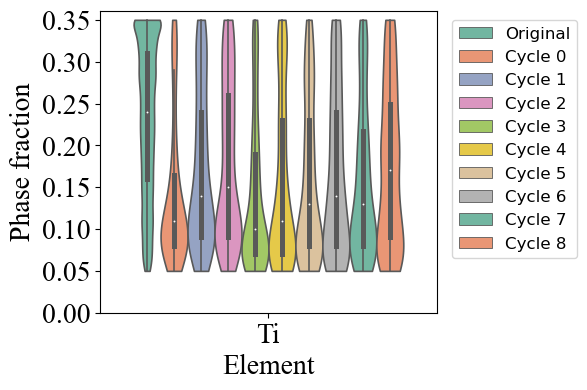

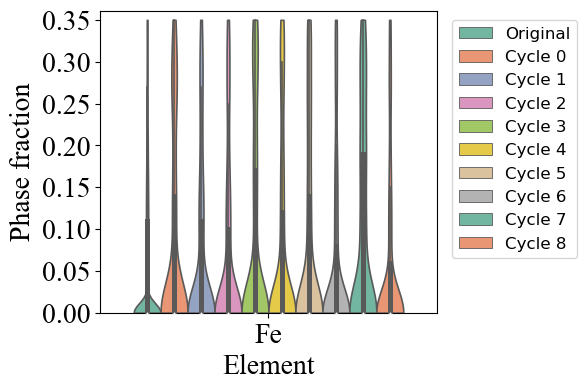

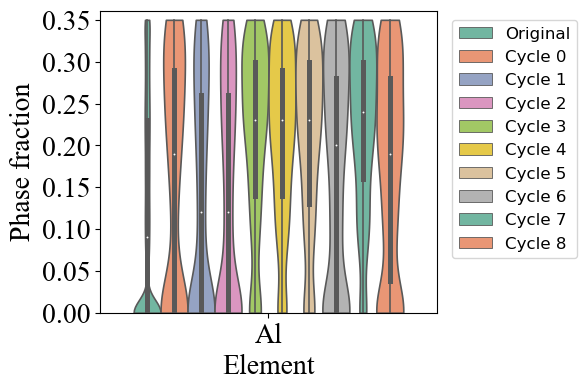

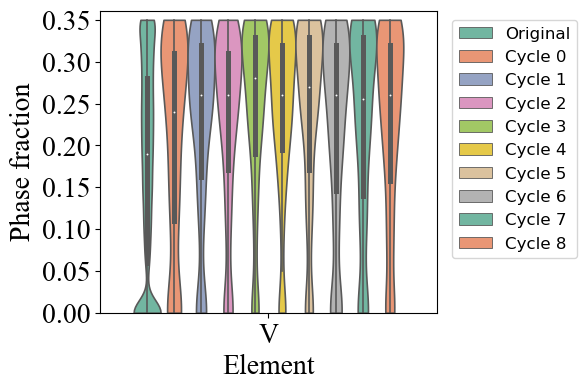

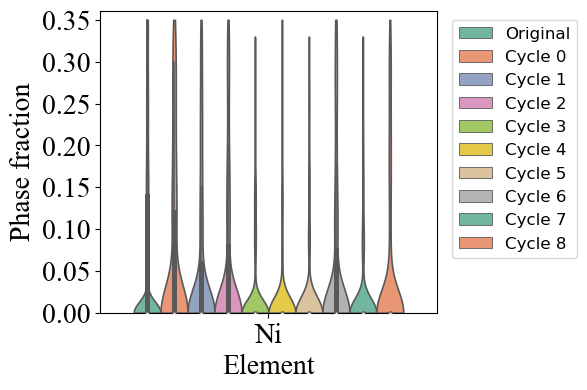

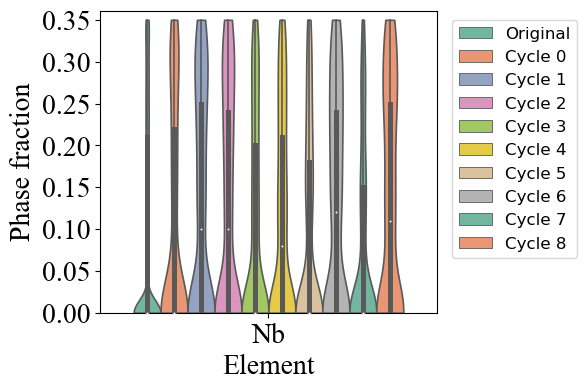

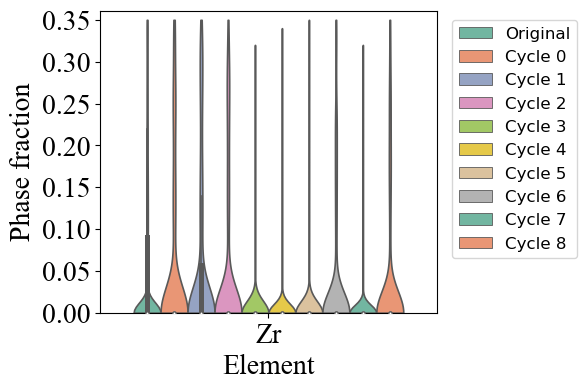

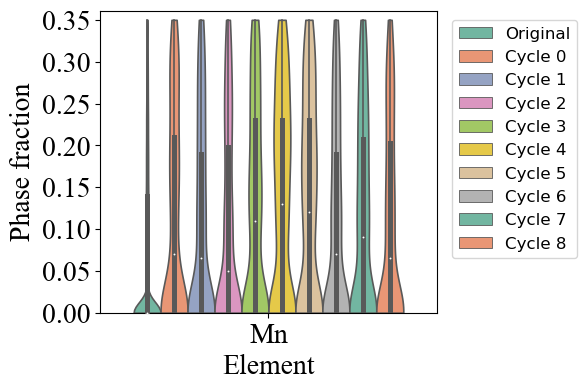

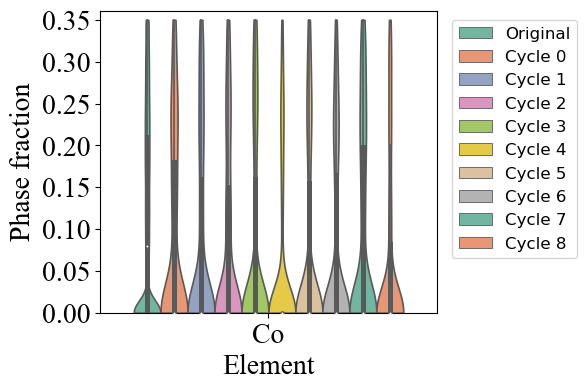

In [88]:
#This code generates Figure 9 of the manuscript wherein each compositional data is obtained via the earlier code  

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

elements = ['Ti', 'Fe', 'Al', 'V', 'Ni', 'Nb', 'Zr', 'Mn', 'Co']
all_data = []
parent = np.load('xlo_test_comp_bcc.npy') #load the bcc compositions of testing dataset
parent_df = pd.DataFrame(parent, columns=elements)
parent_df['Dataset'] = 'Original'
all_data.append(parent_df)

for i in range(9): #how many acitve learning to load
    data = np.load(f'comp{i}.npy') 
    df = pd.DataFrame(data, columns=elements)
    df['Dataset'] = f'Cycle {i}'
    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)
for element in elements:
    df_long = df_all[['Dataset', element]].melt(
        id_vars='Dataset', var_name='Element', value_name='Fraction'
    )
    
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=df_long,
        x='Element',
        y='Fraction',
        hue='Dataset',
        inner='box',
        linewidth=1.2,
        cut=0,
        scale='width',
        palette='Set2',
        dodge=True
    )
    plt.ylim(0, 0.36)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    plt.xlabel("Element", fontsize=20, fontname='Times New Roman')
    plt.ylabel("Phase fraction", fontsize=20, fontname='Times New Roman')
    plt.xticks(fontsize=20, fontname='Times New Roman')
    plt.yticks(fontsize=20, fontname='Times New Roman')
    plt.tight_layout()
    plt.savefig(f'9_{element}.png', dpi=600)
    plt.show()
